In [24]:
import ast, io

import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt

from IPython.display import display, Image
from src.theory.error_bar import *

In [25]:
dim = 4
with open(f'../data/experiment/dim_{dim}/ov0.75_noise0.csv', 'r', encoding='utf-8-sig') as file:
    data = pd.read_csv(file)
print(data.head())

      timestamp optimizer  lambda_val  fixed rate  \
0  260330111329    COBYLA        50.0      0.0000   
1  260330113811    COBYLA        50.0      0.1875   
2  260330121155    COBYLA        50.0      0.3750   
3  260330123853    COBYLA        50.0      0.5625   
4  260330130311    COBYLA        50.0      0.7500   

                                             history  \
0  [[3.3370402829216856, 4.907836282921686, 4.907...   
1  [[1.9185872809425528, 3.489383280942553, 1.918...   
2  [[0.34559235762986373, 1.916388357629864, 1.91...   
3  [[5.846771997707099, 7.417567997707099, 5.8467...   
4  [[1.019739706271678, 2.590535706271678, 2.5905...   

                                            raw_data  
0  [[147.64497132633332, 2.6656562866666667, 6.33...  
1  [[56.658372377666666, -0.0007167499999999999, ...  
2  [[136.64933220666666, 0.33293850266666664, 4.9...  
3  [[50.326589072, 1.9991762, 30.328812821666666,...  
4  [[4.332153805333333, 39.327341493333336, 3.998...  


In [26]:
columns = ['timestamp', 'optimizer', 'lambda_val', 'fixed rate', 'raw_data']
df = data[columns].copy()
print(df)

      timestamp optimizer  lambda_val  fixed rate  \
0  260330111329    COBYLA        50.0      0.0000   
1  260330113811    COBYLA        50.0      0.1875   
2  260330121155    COBYLA        50.0      0.3750   
3  260330123853    COBYLA        50.0      0.5625   
4  260330130311    COBYLA        50.0      0.7500   
5  260330133045    COBYLA        50.0      0.0000   

                                            raw_data  
0  [[147.64497132633332, 2.6656562866666667, 6.33...  
1  [[56.658372377666666, -0.0007167499999999999, ...  
2  [[136.64933220666666, 0.33293850266666664, 4.9...  
3  [[50.326589072, 1.9991762, 30.328812821666666,...  
4  [[4.332153805333333, 39.327341493333336, 3.998...  
5  [[76.65512095666666, 15.330233018666664, 8.331...  


In [27]:
df['raw_data'] = df['raw_data'].apply(ast.literal_eval)
df['raw_data'] = df['raw_data'].apply(lambda m: np.array(m)*dim)
cols = ['success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
df[cols] = df['raw_data'].apply(get_monte_carlo_error)
print(df)

      timestamp optimizer  lambda_val  fixed rate  \
0  260330111329    COBYLA        50.0      0.0000   
1  260330113811    COBYLA        50.0      0.1875   
2  260330121155    COBYLA        50.0      0.3750   
3  260330123853    COBYLA        50.0      0.5625   
4  260330130311    COBYLA        50.0      0.7500   
5  260330133045    COBYLA        50.0      0.0000   

                                            raw_data  success rate  \
0  [[590.5798853053333, 10.662625146666667, 25.32...      0.766940   
1  [[226.63348951066666, -0.0028669999999999998, ...      0.515599   
2  [[546.5973288266666, 1.3317540106666665, 19.99...      0.554314   
3  [[201.306356288, 7.9967048, 121.31525128666667...      0.315164   
4  [[17.328615221333333, 157.30936597333334, 15.9...      0.032844   
5  [[306.62048382666666, 61.32093207466666, 33.32...      0.682501   

   failure rate  error rate  success std  failure std  error std  
0      0.004714    0.228346     0.010062     0.001669   0.010041  
1  

In [30]:
optimizer = df['optimizer'].unique()[0]
columns = ['fixed rate', 'success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
for lambda_val in df['lambda_val'].unique():
    file_name = f"data/[{optimizer}, {dim}dim] lambda={lambda_val} Experiment.csv"
    sep_df = df[df['lambda_val'] == lambda_val][columns]
    sep_df.to_csv(file_name, mode='a', index=False, encoding='utf-8-sig')


In [31]:
dim = 4
lambda_val = 50.0
with open(f'data/[COBYLA, {dim}dim] lambda={lambda_val} Experiment.csv', 'r', encoding='utf-8-sig') as file:
    processed_data = pd.read_csv(file)

with open(f"../data/theory/dim_{dim}/ov0.75.csv", "r", encoding='utf-8-sig') as file:
    theory_df = pd.read_csv(file)

processed_data = processed_data[processed_data['fixed rate'] != 'fixed rate']
processed_data = processed_data.apply(pd.to_numeric)
processed_data = processed_data.reset_index(drop=True)
theory_df = theory_df.apply(pd.to_numeric)

rms_list = []

for idx, row in processed_data.iterrows():
    fixed_rate_val = row['fixed rate']

    fixed_rate_idx = np.abs(theory_df['fixed rate'] - fixed_rate_val).argmin()

    succ_diff = theory_df.iloc[fixed_rate_idx]['success rate'] - row['success rate']
    error_diff = theory_df.iloc[fixed_rate_idx]['error rate'] - row['error rate']
    fail_diff = theory_df.iloc[fixed_rate_idx]['failure rate'] - row['failure rate']

    rms = np.sqrt((succ_diff**2 + error_diff**2 + fail_diff**2) / 3)
    rms_list.append(rms)

processed_data['rms'] = rms_list


0.27065772915994946


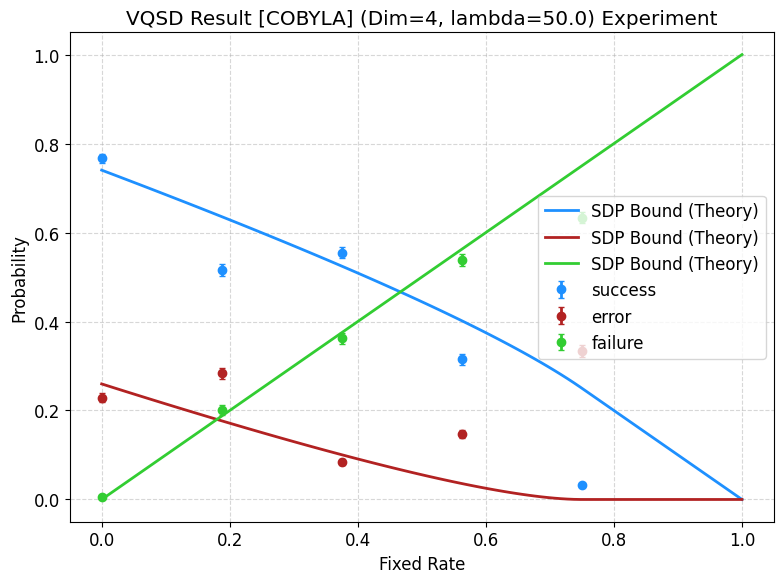

In [32]:
best_idx = processed_data.groupby(['fixed rate'])['rms'].idxmin()
best_processed_data = processed_data.iloc[best_idx]

plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2})
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(theory_df['fixed rate'], theory_df['success rate'], label='SDP Bound (Theory)', color='dodgerblue', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['error rate'], label='SDP Bound (Theory)', color='firebrick', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['failure rate'], label='SDP Bound (Theory)', color='limegreen', linestyle='-')

color = {
    'success': 'dodgerblue',
    'failure': 'limegreen',
    'error': 'firebrick'
}

x = best_processed_data['fixed rate']
for data_type in ['success', 'error', 'failure']:
    ax.errorbar(x, best_processed_data[f'{data_type} rate'], best_processed_data[f'{data_type} std'], fmt='o', color=color[data_type], capsize=2, label=data_type)
ax.set_xlabel('Fixed Rate')
ax.set_ylabel('Probability')
ax.set_title(f'VQSD Result [COBYLA] (Dim={dim}, lambda={lambda_val}) Experiment')
ax.legend(loc='center right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

total_rms = 0
for idx, row in best_processed_data.iterrows():
    if idx != 0:
        total_rms += float(row['rms'])**2
print(np.sqrt(total_rms))

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))
plt.close()